# Задание 2.1 - Нейронные сети

В этом задании вы реализуете и натренируете настоящую нейроную сеть своими руками!

В некотором смысле это будет расширением прошлого задания - нам нужно просто составить несколько линейных классификаторов вместе!

<img src="https://i.redd.it/n9fgba8b0qr01.png" alt="Stack_more_layers" width="400px"/>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# %load_ext autoreload
# %autoreload 2

In [1]:
from dataset import load_svhn, random_split_train_val
from gradient_check import check_layer_gradient, check_layer_param_gradient, check_model_gradient
from layers import FullyConnectedLayer, ReLULayer
from model import TwoLayerNet
from trainer import Trainer, Dataset
from optim import SGD, MomentumSGD
from metrics import multiclass_accuracy

# Загружаем данные

И разделяем их на training и validation.

In [4]:
def prepare_for_neural_network(train_X, test_X):
    train_flat = train_X.reshape(train_X.shape[0], -1).astype(float) / 255.0
    test_flat = test_X.reshape(test_X.shape[0], -1).astype(float) / 255.0
    
    # Subtract mean
    mean_image = np.mean(train_flat, axis = 0)
    train_flat -= mean_image
    test_flat -= mean_image
    
    return train_flat, test_flat
    
train_X, train_y, test_X, test_y = load_svhn("data", max_train=10000, max_test=1000)    
train_X, test_X = prepare_for_neural_network(train_X, test_X)
# Split train into train and val
train_X, train_y, val_X, val_y = random_split_train_val(train_X, train_y, num_val = 1000)

# Как всегда, начинаем с кирпичиков

Мы будем реализовывать необходимые нам слои по очереди. Каждый слой должен реализовать:
- прямой проход (forward pass), который генерирует выход слоя по входу и запоминает необходимые данные
- обратный проход (backward pass), который получает градиент по выходу слоя и вычисляет градиент по входу и по параметрам

Начнем с ReLU, у которого параметров нет.

In [4]:
X = np.array([[1,-2,3], [-1, 2, 0.1]])

assert check_layer_gradient(ReLULayer(), X)

Gradient check passed!


А теперь реализуем полносвязный слой (fully connected layer), у которого будет два массива параметров: W (weights) и B (bias).

Все параметры наши слои будут использовать для параметров специальный класс `Param`, в котором будут храниться значения параметров и градиенты этих параметров, вычисляемые во время обратного прохода.

Это даст возможность аккумулировать (суммировать) градиенты из разных частей функции потерь, например, из cross-entropy loss и regularization loss.

In [5]:
fc = FullyConnectedLayer(3, 4)
output = fc.forward(X)

In [6]:
assert check_layer_gradient(FullyConnectedLayer(3, 4), X)
assert check_layer_param_gradient(FullyConnectedLayer(3, 4), X, 'W')
assert check_layer_param_gradient(FullyConnectedLayer(3, 4), X, 'B')

Gradient check passed!
Gradient check passed!
Gradient check passed!


## Создаем нейронную сеть

Теперь мы реализуем простейшую нейронную сеть с двумя полносвязным слоями и нелинейностью ReLU. Реализуйте функцию `compute_loss_and_gradients`, она должна запустить прямой и обратный проход через оба слоя для вычисления градиентов.

Не забудьте реализовать очистку градиентов в начале функции.

In [7]:
model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 3, reg = 0)
loss = model.compute_loss_and_gradients(train_X[:2], train_y[:2])

check_model_gradient(model, train_X[:2], train_y[:2])

Checking gradient for fc1_w
Gradient check passed!
Checking gradient for fc1_b
Gradient check passed!
Checking gradient for fc2_w
Gradient check passed!
Checking gradient for fc2_b
Gradient check passed!


True

Теперь добавьте к модели регуляризацию - она должна прибавляться к loss и делать свой вклад в градиенты.

In [8]:
model_with_reg = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 3, reg = 1e1)
loss_with_reg = model_with_reg.compute_loss_and_gradients(train_X[:2], train_y[:2])
assert loss_with_reg > loss and not np.isclose(loss_with_reg, loss), \
    "Loss with regularization (%2.4f) should be higher than without it (%2.4f)!" % (loss, loss_with_reg)

check_model_gradient(model_with_reg, train_X[:2], train_y[:2])

Checking gradient for fc1_w
Gradient check passed!
Checking gradient for fc1_b
Gradient check passed!
Checking gradient for fc2_w
Gradient check passed!
Checking gradient for fc2_b
Gradient check passed!


True

Также реализуем функцию предсказания (вычисления значения) модели на новых данных.

Какое значение точности мы ожидаем увидеть до начала тренировки?

In [9]:
# Finally, implement predict function!
# What would be the value we expect?
multiclass_accuracy(model_with_reg.predict(train_X[:30]), train_y[:30]) 

np.float64(0.16666666666666666)

# Допишем код для процесса тренировки

Если все реализовано корректно, значение функции ошибки должно уменьшаться с каждой эпохой, пусть и медленно. Не беспокойтесь пока про validation accuracy.

In [10]:
model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-5)
dataset = Dataset(train_X, train_y, val_X, val_y)
trainer = Trainer(model, dataset, SGD(), learning_rate = 1e-2)

# You should expect loss to go down every epoch, even if it's slow
loss_history, train_history, val_history = trainer.fit()

Loss: 42.655681, Train accuracy: 0.352556, val accuracy: 0.357000
Loss: 32.758178, Train accuracy: 0.553667, val accuracy: 0.559000
Loss: 26.968575, Train accuracy: 0.650444, val accuracy: 0.625000
Loss: 23.842462, Train accuracy: 0.619111, val accuracy: 0.595000
Loss: 22.212012, Train accuracy: 0.704333, val accuracy: 0.671000
Loss: 20.595595, Train accuracy: 0.719778, val accuracy: 0.667000
Loss: 19.452888, Train accuracy: 0.733889, val accuracy: 0.692000
Loss: 18.347316, Train accuracy: 0.723667, val accuracy: 0.664000
Loss: 17.519598, Train accuracy: 0.748444, val accuracy: 0.684000
Loss: 16.829441, Train accuracy: 0.751333, val accuracy: 0.690000
Loss: 16.065492, Train accuracy: 0.765778, val accuracy: 0.683000
Loss: 15.473660, Train accuracy: 0.762667, val accuracy: 0.689000
Loss: 14.616500, Train accuracy: 0.811111, val accuracy: 0.722000
Loss: 14.609044, Train accuracy: 0.787444, val accuracy: 0.709000
Loss: 13.631179, Train accuracy: 0.803000, val accuracy: 0.727000
Loss: 13.4

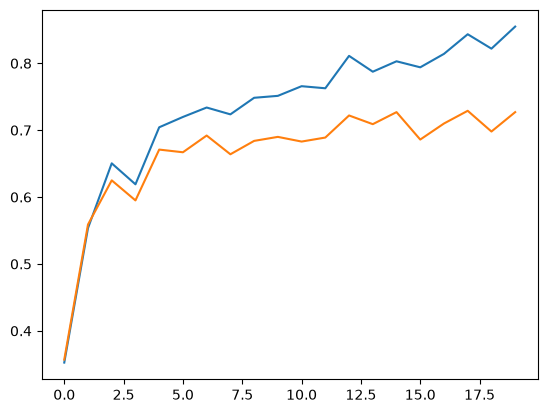

In [11]:
plt.plot(train_history)
plt.plot(val_history)

# Улучшаем процесс тренировки

Мы реализуем несколько ключевых оптимизаций, необходимых для тренировки современных нейросетей.

## Уменьшение скорости обучения (learning rate decay)

Одна из необходимых оптимизаций во время тренировки нейронных сетей - постепенное уменьшение скорости обучения по мере тренировки.

Один из стандартных методов - уменьшение скорости обучения (learning rate) каждые N эпох на коэффициент d (часто называемый decay). Значения N и d, как всегда, являются гиперпараметрами и должны подбираться на основе эффективности на проверочных данных (validation data). 

В нашем случае N будет равным 1.

In [12]:
# Decay should happen once per epoch

model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-5)
dataset = Dataset(train_X, train_y, val_X, val_y)
trainer = Trainer(model, dataset, SGD(), learning_rate_decay=0.99)

initial_learning_rate = trainer.learning_rate
loss_history, train_history, val_history = trainer.fit()

assert trainer.learning_rate < initial_learning_rate, "Learning rate should've been reduced"
assert trainer.learning_rate > 0.5*initial_learning_rate, "Learning rate shouldn'tve been reduced that much!"

Loss: 42.672346, Train accuracy: 0.358778, val accuracy: 0.377000
Loss: 32.834485, Train accuracy: 0.571333, val accuracy: 0.579000
Loss: 26.547315, Train accuracy: 0.595556, val accuracy: 0.553000
Loss: 23.907023, Train accuracy: 0.670444, val accuracy: 0.644000
Loss: 21.537931, Train accuracy: 0.681778, val accuracy: 0.631000
Loss: 20.193976, Train accuracy: 0.633556, val accuracy: 0.606000
Loss: 19.264925, Train accuracy: 0.721778, val accuracy: 0.695000
Loss: 17.873670, Train accuracy: 0.768444, val accuracy: 0.705000
Loss: 17.100987, Train accuracy: 0.762111, val accuracy: 0.701000
Loss: 15.977510, Train accuracy: 0.762889, val accuracy: 0.698000
Loss: 15.102321, Train accuracy: 0.760667, val accuracy: 0.700000
Loss: 14.828761, Train accuracy: 0.797111, val accuracy: 0.720000
Loss: 13.848880, Train accuracy: 0.775667, val accuracy: 0.696000
Loss: 13.555058, Train accuracy: 0.809222, val accuracy: 0.717000
Loss: 12.994687, Train accuracy: 0.761000, val accuracy: 0.690000
Loss: 12.4

# Накопление импульса (Momentum SGD)

Другой большой класс оптимизаций - использование более эффективных методов градиентного спуска. Мы реализуем один из них - накопление импульса (Momentum SGD).

Этот метод хранит скорость движения, использует градиент для ее изменения на каждом шаге, и изменяет веса пропорционально значению скорости.
(Физическая аналогия: Вместо скорости градиенты теперь будут задавать ускорение, но будет присутствовать сила трения.)

```
velocity = momentum * velocity - learning_rate * gradient 
w = w + velocity
```

`momentum` здесь коэффициент затухания, который тоже является гиперпараметром (к счастью, для него часто есть хорошее значение по умолчанию, типичный диапазон -- 0.8-0.99).

Несколько полезных ссылок, где метод разбирается более подробно:  
http://cs231n.github.io/neural-networks-3/#sgd  
https://distill.pub/2017/momentum/

In [13]:
model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-4)
dataset = Dataset(train_X, train_y, val_X, val_y)
trainer = Trainer(model, dataset, MomentumSGD(), learning_rate=1e-3, learning_rate_decay=0.99)

# You should see even better results than before!
loss_history, train_history, val_history = trainer.fit()

Loss: 43.401401, Train accuracy: 0.320667, val accuracy: 0.343000
Loss: 32.633906, Train accuracy: 0.550778, val accuracy: 0.555000
Loss: 26.232019, Train accuracy: 0.626000, val accuracy: 0.612000
Loss: 23.128639, Train accuracy: 0.642333, val accuracy: 0.607000
Loss: 20.992657, Train accuracy: 0.658667, val accuracy: 0.618000
Loss: 19.842863, Train accuracy: 0.720444, val accuracy: 0.665000
Loss: 18.486541, Train accuracy: 0.740444, val accuracy: 0.676000
Loss: 17.537703, Train accuracy: 0.728000, val accuracy: 0.667000
Loss: 16.570177, Train accuracy: 0.747333, val accuracy: 0.694000
Loss: 15.681333, Train accuracy: 0.793111, val accuracy: 0.708000
Loss: 14.947277, Train accuracy: 0.797778, val accuracy: 0.708000
Loss: 14.476762, Train accuracy: 0.779222, val accuracy: 0.691000
Loss: 13.621679, Train accuracy: 0.806000, val accuracy: 0.691000
Loss: 12.475322, Train accuracy: 0.801111, val accuracy: 0.693000
Loss: 12.722717, Train accuracy: 0.852889, val accuracy: 0.732000
Loss: 11.8

# Ну что, давайте уже тренировать сеть!

## Последний тест - переобучимся (overfit) на маленьком наборе данных

Хороший способ проверить, все ли реализовано корректно - переобучить сеть на маленьком наборе данных.  
Наша модель обладает достаточной мощностью, чтобы приблизить маленький набор данных идеально, поэтому мы ожидаем, что на нем мы быстро дойдем до 100% точности на тренировочном наборе. 

Если этого не происходит, то где-то была допущена ошибка!

In [17]:
data_size = 15
model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-1)
dataset = Dataset(train_X[:data_size], train_y[:data_size], val_X[:data_size], val_y[:data_size])
trainer = Trainer(model, dataset, SGD(), learning_rate=1e-2, num_epochs=150, batch_size=5)

# You should expect this to reach 1.0 training accuracy 
loss_history, train_history, val_history = trainer.fit()

Loss: 11.547190, Train accuracy: 0.200000, val accuracy: 0.133333
Loss: 11.518354, Train accuracy: 0.200000, val accuracy: 0.133333
Loss: 11.493652, Train accuracy: 0.200000, val accuracy: 0.133333
Loss: 11.462797, Train accuracy: 0.200000, val accuracy: 0.133333
Loss: 11.449215, Train accuracy: 0.200000, val accuracy: 0.133333
Loss: 11.415132, Train accuracy: 0.200000, val accuracy: 0.133333
Loss: 11.390881, Train accuracy: 0.200000, val accuracy: 0.133333
Loss: 11.351091, Train accuracy: 0.200000, val accuracy: 0.133333
Loss: 11.322074, Train accuracy: 0.200000, val accuracy: 0.133333
Loss: 11.295603, Train accuracy: 0.200000, val accuracy: 0.133333
Loss: 11.238670, Train accuracy: 0.200000, val accuracy: 0.066667
Loss: 11.181877, Train accuracy: 0.200000, val accuracy: 0.066667
Loss: 11.081302, Train accuracy: 0.266667, val accuracy: 0.000000
Loss: 10.980176, Train accuracy: 0.266667, val accuracy: 0.000000
Loss: 10.768454, Train accuracy: 0.400000, val accuracy: 0.000000
Loss: 10.5

Теперь найдем гипепараметры, для которых этот процесс сходится быстрее.
Если все реализовано корректно, то существуют параметры, при которых процесс сходится в **20** эпох или еще быстрее.
Найдите их!

In [ ]:
# Now, tweak some hyper parameters and make it train to 1.0 accuracy in 20 epochs or less

model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-2)
dataset = Dataset(train_X[:data_size], train_y[:data_size], val_X[:data_size], val_y[:data_size])
trainer = Trainer(model, dataset, MomentumSGD(), learning_rate=1e-2, num_epochs=20, batch_size=5)

loss_history, train_history, val_history = trainer.fit()

Loss: 11.533804, Train accuracy: 0.200000, val accuracy: 0.066667
Loss: 11.485671, Train accuracy: 0.200000, val accuracy: 0.066667
Loss: 11.335213, Train accuracy: 0.200000, val accuracy: 0.066667
Loss: 11.145412, Train accuracy: 0.200000, val accuracy: 0.066667
Loss: 10.961583, Train accuracy: 0.200000, val accuracy: 0.133333
Loss: 10.572444, Train accuracy: 0.400000, val accuracy: 0.000000
Loss: 9.845796, Train accuracy: 0.400000, val accuracy: 0.000000
Loss: 8.814022, Train accuracy: 0.333333, val accuracy: 0.000000
Loss: 8.077699, Train accuracy: 0.400000, val accuracy: 0.000000
Loss: 7.328930, Train accuracy: 0.466667, val accuracy: 0.133333
Loss: 6.950666, Train accuracy: 0.533333, val accuracy: 0.000000
Loss: 6.526501, Train accuracy: 0.600000, val accuracy: 0.066667
Loss: 5.654767, Train accuracy: 0.666667, val accuracy: 0.000000
Loss: 4.653050, Train accuracy: 0.733333, val accuracy: 0.066667
Loss: 4.319322, Train accuracy: 0.800000, val accuracy: 0.133333
Loss: 3.631961, Tra

# Итак, основное мероприятие!

Натренируйте лучшую нейросеть! Можно добавлять и изменять параметры, менять количество нейронов в слоях сети и как угодно экспериментировать. 

Добейтесь точности лучше **60%** на validation set.

In [ ]:
# Let's train the best one-hidden-layer network we can

learning_rates = [1e-2, 1e-3, 1e-4]
reg_strength = [1e-2, 1e-3, 1e-4]
learning_rate_decay = 0.999
hidden_layer_size = [64, 128, 256]
num_epochs = 200
batch_size = 64
optim_classes = [SGD, MomentumSGD]

best_classifier = None
best_val_accuracy = 0

loss_history = []
train_history = []
val_history = []

dataset = Dataset(train_X, train_y, val_X, val_y)
for lr in learning_rates:
    for reg in reg_strength:
        for hls in hidden_layer_size:
            for optim_class in optim_classes:
                optim = optim_class()
                model = TwoLayerNet(n_input = train_X.shape[1], n_output=10, hidden_layer_size=hls, reg=reg)
                trainer = Trainer(model, dataset, optim, learning_rate=lr, num_epochs=num_epochs, batch_size=batch_size, learning_rate_decay=learning_rate_decay)

                loss_history, train_history, val_history = trainer.fit()
                print(
                    f"lr={lr}, reg={reg}, hidden={hls}, "
                    f"optim={optim_class.__name__}, "
                    f"val={val_history[-1]:.4f}"
                )

                if val_history[-1] > best_val_accuracy:
                    best_val_accuracy = val_history[-1]
                    best_classifier = model

                    loss_history_best = loss_history
                    train_history_best = train_history
                    val_history_best = val_history

print('best validation accuracy achieved: %f' % best_val_accuracy)

lr=0.01, reg=0.01, hidden=64, optim=SGD, val=0.6960
lr=0.01, reg=0.01, hidden=64, optim=MomentumSGD, val=0.0490
lr=0.01, reg=0.01, hidden=128, optim=SGD, val=0.0490
lr=0.01, reg=0.01, hidden=128, optim=MomentumSGD, val=0.0490
lr=0.01, reg=0.01, hidden=256, optim=SGD, val=0.7320
lr=0.01, reg=0.01, hidden=256, optim=MomentumSGD, val=0.0490
lr=0.01, reg=0.001, hidden=64, optim=SGD, val=0.7370
lr=0.01, reg=0.001, hidden=64, optim=MomentumSGD, val=0.0490
lr=0.01, reg=0.001, hidden=128, optim=SGD, val=0.7610
lr=0.01, reg=0.001, hidden=128, optim=MomentumSGD, val=0.0490
lr=0.01, reg=0.001, hidden=256, optim=SGD, val=0.0490
lr=0.01, reg=0.001, hidden=256, optim=MomentumSGD, val=0.0490
lr=0.01, reg=0.0001, hidden=64, optim=SGD, val=0.7380
lr=0.01, reg=0.0001, hidden=64, optim=MomentumSGD, val=0.0490
lr=0.01, reg=0.0001, hidden=128, optim=SGD, val=0.7750
lr=0.01, reg=0.0001, hidden=128, optim=MomentumSGD, val=0.0490
lr=0.01, reg=0.0001, hidden=256, optim=SGD, val=0.7710
lr=0.01, reg=0.0001, hidd

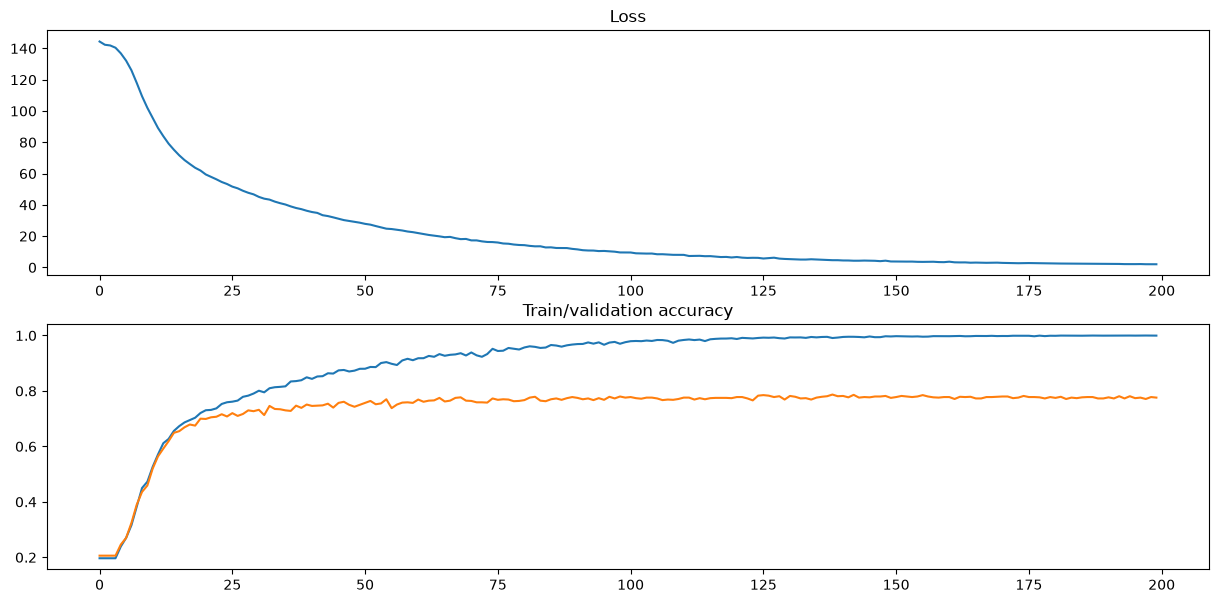

In [12]:
plt.figure(figsize=(15, 7))
plt.subplot(211)
plt.title("Loss")
plt.plot(loss_history)
plt.subplot(212)
plt.title("Train/validation accuracy")
plt.plot(train_history)
plt.plot(val_history)

# Как обычно, посмотрим, как наша лучшая модель работает на тестовых данных

In [13]:
test_pred = best_classifier.predict(test_X)
test_accuracy = multiclass_accuracy(test_pred, test_y)
print('Neural net test set accuracy: %f' % (test_accuracy, ))

Neural net test set accuracy: 0.762000
